# 06 Modeling

CRISP-DM Phase 4: Modellierung. Ziel dieses Notebooks ist es, systematisch mehrere
Modell-Familien zu evaluieren und das beste Modell für den nachgelagerten Evaluierungs-
und Kalibrierungsschritt bereitzustellen.

**Absolute Leakage-Regeln dieses Notebooks:**
- `X_test` / `y_test` werden nicht geladen.
- Skalierung, SMOTE und Feature-Selektion ausschließlich innerhalb von Pipelines
  (pro CV-Fold neu gefittet).
- RFECV verwendet eine sklearn-Pipeline als Estimator, damit der StandardScaler
  keine Validierungsfold-Information enthält.
- `imblearn.pipeline.Pipeline` für alle SMOTE-Experimente.

**Struktur:**
1. Setup
2. Daten laden
3. No-Skill Baseline (Dummy)
4. Duplikat-Ablation
5. Raw 21 vs. Enriched 32 Features
6. Imbalance-Strategien
7. Feature-Selektion (ElasticNet + RFECV)
8. Großer Modellvergleich
9. Finales Modell
10. Export
11. Zusammenfassung

## 1. Setup

Alle Bibliotheken werden zentral importiert. `SEED = 42` wird an einer einzigen Stelle
festgelegt und in allen randomisierten Operationen verwendet, um vollständige
Reproduzierbarkeit zu garantieren. Für den RFECV-Leakage-Fix wird zusätzlich
`sklearn.pipeline.Pipeline` importiert (parallel zur `imblearn.pipeline.Pipeline`).

In [1]:
import importlib, subprocess, sys
for pkg in ['imbalanced-learn', 'xgboost', 'lightgbm', 'catboost', 'pyarrow']:
    if importlib.util.find_spec(pkg.replace('-', '_')) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import warnings
warnings.filterwarnings('ignore')

import json
import time
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_validate, cross_val_predict
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.feature_selection import RFECV
from sklearn.metrics import precision_recall_curve, average_precision_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)

# --- Pfade (analog zu NB05) ---
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
OUTPUTS_DIR   = Path('../outputs/06_modeling')

for d in [MODELS_DIR, OUTPUTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Setup abgeschlossen.')
print(f'  PROCESSED_DIR : {PROCESSED_DIR.resolve()}')
print(f'  MODELS_DIR    : {MODELS_DIR.resolve()}')
print(f'  OUTPUTS_DIR   : {OUTPUTS_DIR.resolve()}')

Setup abgeschlossen.
  PROCESSED_DIR : C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\data\processed
  MODELS_DIR    : C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\models
  OUTPUTS_DIR   : C:\Users\hashe\Downloads\Diabetes-Prediction-Hasher\outputs\06_modeling


## 2. Daten laden

`X_train` enthält die 21 Original-Features aus NB03. `X_train_enriched` enthält die
32 Features nach Feature-Engineering (NB05). `y_train` wird als DataFrame gespeichert
und mit `.squeeze()` in eine Series umgewandelt.

`X_test` / `y_test` werden in diesem Notebook **nicht** geladen — das Testset bleibt
eingefroren bis zur finalen Evaluation.

In [2]:
X_train          = pd.read_parquet(PROCESSED_DIR / 'X_train.parquet')
X_train_enriched = pd.read_parquet(PROCESSED_DIR / 'X_train_enriched.parquet')
y_train          = pd.read_parquet(PROCESSED_DIR / 'y_train.parquet').squeeze()

# Klassen-Verhältnis für scale_pos_weight / spw
spw = (y_train == 0).sum() / (y_train == 1).sum()

# CV-Strategie: einmalig definiert, überall konsistent verwendet
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = 'average_precision'  # = PR-AUC

print(f'X_train shape          : {X_train.shape}')
print(f'X_train_enriched shape : {X_train_enriched.shape}')
print(f'y_train shape          : {y_train.shape}')
print(f'y_train type           : {type(y_train).__name__}')
print(f'Prävalenz (positive)   : {y_train.mean():.4f}')
print(f'scale_pos_weight (spw) : {spw:.4f}')
print(f'Kein X_test geladen    : OK')

X_train shape          : (202944, 21)
X_train_enriched shape : (202944, 32)
y_train shape          : (202944,)
y_train type           : Series
Prävalenz (positive)   : 0.1393
scale_pos_weight (spw) : 6.1770
Kein X_test geladen    : OK


## 3. No-Skill Baseline (Dummy)

Bevor irgendein lernbasiertes Modell evaluiert wird, wird die absolute Untergrenze
festgelegt: ein Modell, das keinerlei Mustererkennung betreibt.

- `most_frequent`: gibt immer die Mehrheitsklasse (0) aus → Precision für die positive
  Klasse ist nicht definierbar; PR-AUC kollabiert auf die Prävalenz.
- `stratified`: zieht zufällig gemäß Klassenverteilung → auch hier liegt die erwartete
  PR-AUC nahe der Prävalenz.

PR-AUC ≈ Prävalenz ≈ 0,139 ist die absolute Untergrenze, die jedes sinnvolle Modell
übertreffen muss.

In [3]:
dummy_results = []
for strategy in ['most_frequent', 'stratified']:
    dummy = DummyClassifier(strategy=strategy, random_state=SEED)
    scores = cross_val_score(dummy, X_train_enriched, y_train,
                             cv=cv, scoring=SCORING, n_jobs=-1)
    dummy_results.append({
        'Strategie': strategy,
        'mean PR-AUC': round(scores.mean(), 4),
        'std PR-AUC':  round(scores.std(),  4),
    })

df_dummy = pd.DataFrame(dummy_results)
print('Dummy-Baseline:')
print(df_dummy.to_string(index=False))

df_dummy.to_csv(OUTPUTS_DIR / 'cv_results_dummy.csv', index=False)
print('\ncv_results_dummy.csv gespeichert.')

Dummy-Baseline:
    Strategie  mean PR-AUC  std PR-AUC
most_frequent       0.1393      0.0000
   stratified       0.1393      0.0003

cv_results_dummy.csv gespeichert.


**Interpretation:** Beide Dummy-Strategien liefern eine PR-AUC nahe der Klassen-Prävalenz
von ≈ 0,139. Das entspricht dem theoretisch erwarteten No-Skill-Wert für PR-AUC bei
binärer Klassifikation mit Klassenungleichgewicht. Jeder Modellkandidat in den folgenden
Abschnitten muss diese Schwelle deutlich übertreffen, um als nützlich zu gelten.

## 4. Duplikat-Ablation

Duplikate im Trainingset können die CV-Performance aufblähen: Wenn identische Zeilen
in Trainings- und Validierungsfold landen, misst die CV teilweise Memorisierung statt
Generalisierung. Dieser Abschnitt quantifiziert den Effekt.

Als Referenzmodell wird Logistic Regression gewählt, weil sie deterministisch,
schnell und sensitiv gegenüber Datenzusammensetzung ist.

In [4]:
n_dups = X_train.duplicated().sum()
print(f'Duplikate in X_train: {n_dups:,}')

ref_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   class_weight='balanced', max_iter=2000, random_state=SEED))
])

dedup_results = []

# Variante 1: mit Duplikaten
scores_with = cross_val_score(ref_pipe, X_train, y_train,
                               cv=cv, scoring=SCORING, n_jobs=-1)
dedup_results.append({
    'Variante':     'Mit Duplikaten',
    'n_samples':    len(X_train),
    'mean PR-AUC':  round(scores_with.mean(), 4),
    'std PR-AUC':   round(scores_with.std(),  4),
})

if n_dups > 0:
    df_combined = pd.concat([X_train, y_train.rename('y')], axis=1)
    df_dedup    = df_combined.drop_duplicates()
    X_dedup     = df_dedup.drop(columns=['y'])
    y_dedup     = df_dedup['y']

    scores_dedup = cross_val_score(ref_pipe, X_dedup, y_dedup,
                                   cv=cv, scoring=SCORING, n_jobs=-1)
    dedup_results.append({
        'Variante':     'Ohne Duplikate',
        'n_samples':    len(X_dedup),
        'mean PR-AUC':  round(scores_dedup.mean(), 4),
        'std PR-AUC':   round(scores_dedup.std(),  4),
    })
else:
    dedup_results.append({
        'Variante':    'Ohne Duplikate',
        'n_samples':   len(X_train),
        'mean PR-AUC': dedup_results[0]['mean PR-AUC'],
        'std PR-AUC':  dedup_results[0]['std PR-AUC'],
    })

df_dedup_results = pd.DataFrame(dedup_results)
print('\nDuplikat-Ablation (LogReg, raw 21 Features):')
print(df_dedup_results.to_string(index=False))

df_dedup_results.to_csv(OUTPUTS_DIR / 'cv_results_dedup.csv', index=False)
print('\ncv_results_dedup.csv gespeichert.')

Duplikate in X_train: 18,580

Duplikat-Ablation (LogReg, raw 21 Features):
      Variante  n_samples  mean PR-AUC  std PR-AUC
Mit Duplikaten     202944       0.4060      0.0041
Ohne Duplikate     185446       0.4082      0.0031

cv_results_dedup.csv gespeichert.


**Interpretation:** Falls Duplikate in X_train existieren, sind sie mit hoher
Wahrscheinlichkeit auch im Test vorhanden (da beide aus demselben Rohdatensatz stammen).
Das bedeutet: die spätere Test-PR-AUC wird systematisch überschätzt. **Empfehlung:
`drop_duplicates()` vor dem stratifizierten Split in NB03 nachziehen.**

Für die nachfolgenden Sektionen wird der ursprüngliche `X_train` / `X_train_enriched`
verwendet, um konsistent zum (unveränderten) Test-Set zu bleiben.

## 5. Raw 21 vs. Enriched 32 — Wert von Feature-Engineering quantifizieren

NB05 hat aus den 21 Original-Features 32 angereicherte Features gebaut (Hurdle-Encoding,
BMI-Capping, BMI-Kategorien, Composite-Features). Dieser Abschnitt misst, wieviel
dieser Mehraufwand tatsächlich bringt — gemessen an der 5-Fold CV PR-AUC.

Zwei repräsentative Modelle werden verglichen: Logistic Regression (linearer Baseline)
und XGBoost (nichtlinearer Gradient-Booster).

In [5]:
pipe_lr = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   class_weight='balanced', max_iter=2000, random_state=SEED))
])

xgb_model = XGBClassifier(
    scale_pos_weight=spw, eval_metric='aucpr',
    random_state=SEED, n_jobs=-1
)

fe_experiments = [
    ('LogReg', 'Raw 21',      pipe_lr,   X_train,          y_train),
    ('LogReg', 'Enriched 32', pipe_lr,   X_train_enriched, y_train),
    ('XGB',    'Raw 21',      xgb_model, X_train,          y_train),
    ('XGB',    'Enriched 32', xgb_model, X_train_enriched, y_train),
]

fe_results = []
for model_name, feat_name, model, X_feat, y_feat in fe_experiments:
    scores = cross_val_score(model, X_feat, y_feat,
                             cv=cv, scoring=SCORING, n_jobs=-1)
    fe_results.append({
        'Modell':      model_name,
        'Featureset':  feat_name,
        'mean PR-AUC': round(scores.mean(), 4),
        'std PR-AUC':  round(scores.std(),  4),
    })
    print(f'  {model_name:6s} | {feat_name:12s} | {scores.mean():.4f} ± {scores.std():.4f}')

df_fe = pd.DataFrame(fe_results)

# Delta berechnen
for m in ['LogReg', 'XGB']:
    raw_auc  = df_fe.loc[(df_fe['Modell'] == m) & (df_fe['Featureset'] == 'Raw 21'),      'mean PR-AUC'].values[0]
    enr_auc  = df_fe.loc[(df_fe['Modell'] == m) & (df_fe['Featureset'] == 'Enriched 32'), 'mean PR-AUC'].values[0]
    df_fe.loc[(df_fe['Modell'] == m) & (df_fe['Featureset'] == 'Enriched 32'),
              'Δ Enriched-vs-Raw'] = round(enr_auc - raw_auc, 4)

df_fe['Δ Enriched-vs-Raw'] = df_fe['Δ Enriched-vs-Raw'].fillna('')

print('\nFeature-Engineering-Effekt:')
print(df_fe.to_string(index=False))

df_fe.to_csv(OUTPUTS_DIR / 'cv_results_raw_vs_enriched.csv', index=False)
print('\ncv_results_raw_vs_enriched.csv gespeichert.')

  LogReg | Raw 21       | 0.4060 ± 0.0041
  LogReg | Enriched 32  | 0.4229 ± 0.0053
  XGB    | Raw 21       | 0.4234 ± 0.0062
  XGB    | Enriched 32  | 0.4211 ± 0.0057

Feature-Engineering-Effekt:
Modell  Featureset  mean PR-AUC  std PR-AUC Δ Enriched-vs-Raw
LogReg      Raw 21       0.4060      0.0041                  
LogReg Enriched 32       0.4229      0.0053            0.0169
   XGB      Raw 21       0.4234      0.0062                  
   XGB Enriched 32       0.4211      0.0057           -0.0023

cv_results_raw_vs_enriched.csv gespeichert.


**Interpretation:** Das Delta zeigt, wieviel Feature-Engineering pro Modelltyp bringt.
Baumbasierte Modelle wie XGBoost profitieren in der Regel weniger von manuellem
Feature-Engineering (sie können nichtlineare Relationen intern erlernen), während
Logistic Regression stärker auf explizite Transformationen angewiesen ist.
Das bessere Featureset (Enriched 32) wird in allen nachfolgenden Sektionen verwendet.

## 6. Imbalance-Strategien: Vanilla vs. scale_pos_weight vs. SMOTE

Klassenungleichgewicht (~86 % / ~14 %) erfordert eine bewusste Strategie. Drei
Ansätze werden verglichen:

- **Vanilla:** Kein Ausgleich — das Modell optimiert auf Mehrheitsklasse.
- **scale_pos_weight:** XGBoost gewichtet die positive Klasse um Faktor spw ≈ 6,18
  höher in der Loss-Funktion.
- **SMOTE:** Synthetische Überabtastung der Minderheitsklasse *im Trainingsfold*
  (via imblearn-Pipeline — kein Leakage in den Validierungsfold).

Als Modell wird XGBoost gewählt, weil es alle drei Strategien unterstützt und einen
klaren Head-to-Head-Vergleich ermöglicht.

In [6]:
imb_setups = [
    ('Vanilla',           XGBClassifier(
                              random_state=SEED, n_jobs=-1, eval_metric='aucpr')),
    ('scale_pos_weight',  XGBClassifier(
                              scale_pos_weight=spw, eval_metric='aucpr',
                              random_state=SEED, n_jobs=-1)),
    ('SMOTE',             ImbPipeline([
                              ('smote', SMOTE(random_state=SEED)),
                              ('clf',   XGBClassifier(
                                            random_state=SEED, n_jobs=-1,
                                            eval_metric='aucpr'))
                          ])),
]

imb_results = []
for label, model in imb_setups:
    scores = cross_val_score(model, X_train_enriched, y_train,
                             cv=cv, scoring=SCORING, n_jobs=-1)
    imb_results.append({
        'Strategie':   label,
        'mean PR-AUC': round(scores.mean(), 4),
        'std PR-AUC':  round(scores.std(),  4),
    })
    print(f'  {label:20s} | {scores.mean():.4f} ± {scores.std():.4f}')

df_imb = pd.DataFrame(imb_results)
print('\nImbalance-Strategien (XGB, Enriched 32):')
print(df_imb.to_string(index=False))

df_imb.to_csv(OUTPUTS_DIR / 'cv_results_imbalance.csv', index=False)
print('\ncv_results_imbalance.csv gespeichert.')

  Vanilla              | 0.4194 ± 0.0031
  scale_pos_weight     | 0.4211 ± 0.0057
  SMOTE                | 0.3737 ± 0.0045

Imbalance-Strategien (XGB, Enriched 32):
       Strategie  mean PR-AUC  std PR-AUC
         Vanilla       0.4194      0.0031
scale_pos_weight       0.4211      0.0057
           SMOTE       0.3737      0.0045

cv_results_imbalance.csv gespeichert.


**Interpretation:** Die beste Strategie nach mean PR-AUC wird in Sektion 8 als
Default für XGBoost übernommen.

**Wichtiger Hinweis zu SMOTE:** SMOTE kann die Wahrscheinlichkeits-Kalibrierung
eines Modells verschlechtern, weil synthetisch generierte Samples die empirische
Klassenverteilung im Trainingsfold verzerren. Van den Goorbergh et al. (2022,
*Statistics in Medicine*) zeigen, dass SMOTE-trainierte Modelle systematisch
überhöhte predicted probabilities für die Minderheitsklasse erzeugen. Falls
Kalibrierung in NB07 gewünscht ist, empfiehlt sich `scale_pos_weight` / `class_weight`
als Alternative.

## 7. Feature-Selektion auf Enriched 32 (ElasticNet + RFECV)

Mit 32 Features besteht Redundanz (z. B. `BMI`, `BMI_capped`, `BMI_cat`).
Zwei komplementäre Methoden werden angewendet:

- **ElasticNet (eingebettet):** L1-Regularisierung setzt redundante Koeffizienten
  auf exakt 0. `l1_ratio=0.5` kombiniert Lasso- und Ridge-Penalty. Lasso
  entscheidet automatisch zwischen korrelierten Features — die nicht genutzten
  erhalten Koeffizient 0.
- **RFECV (Wrapper):** Rekursive Feature-Elimination mit CV-gesteuerter Stoppregel.
  Unabhängige Gegenkontrolle zur eingebetteten Methode. Der Estimator wird als
  **sklearn-Pipeline (Scaler + LogReg)** übergeben, damit der StandardScaler
  innerhalb jedes RFECV-CV-Folds neu gefittet wird und keine Validierungsfold-
  Information enthält (Leakage-freie Implementierung).

Die Schnittmenge beider Methoden ist der konservativste Feature-Set.
`CholCheck` wird trotz etwaiger Selektion explizit ausgeschlossen — Begründung
siehe NB04 (Feature Diagnostics: strukturell quasi-konstant, IV ≈ 0, kein
Diskriminierungsbeitrag).

In [7]:
# --- A) ElasticNet (eingebettet) ---
enet_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   penalty='elasticnet', l1_ratio=0.5, C=1,
                   solver='saga', class_weight='balanced',
                   max_iter=5000, random_state=SEED))
])

enet_scores = cross_val_score(enet_pipe, X_train_enriched, y_train,
                               cv=cv, scoring=SCORING, n_jobs=-1)
print(f'ElasticNet CV PR-AUC: {enet_scores.mean():.4f} ± {enet_scores.std():.4f}')

# Einmal auf gesamtem X_train_enriched fitten, um Koeffizienten zu extrahieren
enet_pipe_full = ImbPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   penalty='elasticnet', l1_ratio=0.5, C=1,
                   solver='saga', class_weight='balanced',
                   max_iter=5000, random_state=SEED))
])
enet_pipe_full.fit(X_train_enriched, y_train)

coef_series = pd.Series(
    enet_pipe_full.named_steps['clf'].coef_[0],
    index=X_train_enriched.columns
)
selected_enet = coef_series[coef_series != 0].abs().sort_values(ascending=False)

print(f'\nAnzahl Features mit coef != 0: {len(selected_enet)} / {X_train_enriched.shape[1]}')
print('\nTop-Features nach |coef|:')
print(selected_enet.head(20).to_string())

ElasticNet CV PR-AUC: 0.4229 ± 0.0053

Anzahl Features mit coef != 0: 29 / 32

Top-Features nach |coef|:
GenHlth               1.094528
Age_x_GenHlth         0.631978
BMI_x_Age             0.572331
BMI_capped            0.501419
HighBP                0.323971
BMI                   0.317649
Age                   0.293455
CholCheck             0.243071
metsyn_proxy          0.174391
cardio_comorbidity    0.170870
HvyAlcoholConsump     0.170406
BMI_x_HighBP          0.130127
HighChol              0.127859
ses_index             0.095435
findrisc_lite         0.068721
MentHlth_any          0.064614
PhysHlth_days         0.063493
BMI_cat               0.042580
PhysHlth_any          0.041496
Fruits                0.032462


In [8]:
# --- B) RFECV (Wrapper) ---
# Pipeline-Estimator: Scaler wird pro RFECV-CV-Fold neu gefittet -> kein Leakage
# importance_getter zeigt RFECV explizit auf die Koeffizienten im clf-Schritt,
# da Pipeline.coef_ nicht automatisch delegiert wird (sklearn >= 1.2)
rfecv_pipe = SklearnPipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                   class_weight='balanced', max_iter=2000, random_state=SEED))
])

rfecv = RFECV(
    estimator=rfecv_pipe,
    step=2,
    cv=cv,
    scoring='average_precision',
    importance_getter='named_steps.clf.coef_',
    n_jobs=-1
)
rfecv.fit(X_train_enriched, y_train)

selected_rfecv = list(X_train_enriched.columns[rfecv.support_])
print(f'RFECV optimale Feature-Anzahl: {rfecv.n_features_} / {X_train_enriched.shape[1]}')
print('\nAusgewaehlte Features (RFECV) vor CholCheck-Bereinigung:')
print(selected_rfecv)


RFECV optimale Feature-Anzahl: 20 / 32

Ausgewaehlte Features (RFECV) vor CholCheck-Bereinigung:
['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HvyAlcoholConsump', 'GenHlth', 'DiffWalk', 'Age', 'BMI_capped', 'BMI_cat', 'MentHlth_any', 'PhysHlth_days', 'cardio_comorbidity', 'allostatic_load', 'metsyn_proxy', 'ses_index', 'findrisc_lite', 'BMI_x_Age', 'BMI_x_HighBP', 'Age_x_GenHlth']


In [9]:
# --- C) CholCheck-Bereinigung und Schnittmenge ---
# CholCheck wird explizit ausgeschlossen: NB04 hat das Feature als strukturell
# quasi-konstant (~96 % positiv) mit IV ≈ 0 klassifiziert. Es trägt keinen
# eigenständigen Diskriminierungsbeitrag und sollte unabhängig von RFECV-Ergebnissen
# nicht im Featureset verbleiben.
EXCLUDE_ALWAYS = {'CholCheck'}

n_rfecv_before = len(selected_rfecv)
selected_rfecv = [f for f in selected_rfecv if f not in EXCLUDE_ALWAYS]
if n_rfecv_before != len(selected_rfecv):
    removed = EXCLUDE_ALWAYS & set(X_train_enriched.columns[rfecv.support_])
    print(f'CholCheck-Bereinigung: {removed} aus RFECV-Auswahl entfernt (NB04-Befund)')

selected_enet_list = [f for f in list(selected_enet.index) if f not in EXCLUDE_ALWAYS]
intersection = sorted(set(selected_enet_list) & set(selected_rfecv))

print(f'ElasticNet   : {len(selected_enet_list):2d} Features (nach CholCheck-Ausschluss)')
print(f'RFECV        : {len(selected_rfecv):2d} Features (nach CholCheck-Ausschluss)')
print(f'Schnittmenge : {len(intersection):2d} Features')
print(f'\nSchnittmenge:')
print(intersection)

# Speichern
selected_features_dict = {
    'elasticnet':   selected_enet_list,
    'rfecv':        selected_rfecv,
    'intersection': intersection,
    'excluded':     list(EXCLUDE_ALWAYS),
}
with open(OUTPUTS_DIR / 'selected_features.json', 'w') as f:
    json.dump(selected_features_dict, f, indent=2)
print('\nselected_features.json gespeichert.')

CholCheck-Bereinigung: {'CholCheck'} aus RFECV-Auswahl entfernt (NB04-Befund)
ElasticNet   : 28 Features (nach CholCheck-Ausschluss)
RFECV        : 19 Features (nach CholCheck-Ausschluss)
Schnittmenge : 18 Features

Schnittmenge:
['Age', 'Age_x_GenHlth', 'BMI', 'BMI_capped', 'BMI_cat', 'BMI_x_Age', 'BMI_x_HighBP', 'DiffWalk', 'GenHlth', 'HighBP', 'HighChol', 'HvyAlcoholConsump', 'MentHlth_any', 'PhysHlth_days', 'cardio_comorbidity', 'findrisc_lite', 'metsyn_proxy', 'ses_index']

selected_features.json gespeichert.


In [10]:
# --- D) Sanity-Check: LogReg auf Schnittmenge ---
if len(intersection) == 0:
    print('Schnittmenge leer — Sanity-Check übersprungen.')
else:
    X_intersect = X_train_enriched[intersection]
    intersect_pipe = ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
                       class_weight='balanced', max_iter=2000, random_state=SEED))
    ])
    scores_intersect = cross_val_score(intersect_pipe, X_intersect, y_train,
                                        cv=cv, scoring=SCORING, n_jobs=-1)

    print(f'LogReg (alle 32 Features)     CV PR-AUC: {enet_scores.mean():.4f} ± {enet_scores.std():.4f}')
    print(f'LogReg (Schnittmenge {len(intersection):2d} Feat.) CV PR-AUC: {scores_intersect.mean():.4f} ± {scores_intersect.std():.4f}')
    delta_intersect = scores_intersect.mean() - enet_scores.mean()
    print(f'Δ (Schnittmenge vs. alle)     : {delta_intersect:+.4f}')

LogReg (alle 32 Features)     CV PR-AUC: 0.4229 ± 0.0053
LogReg (Schnittmenge 18 Feat.) CV PR-AUC: 0.4215 ± 0.0054
Δ (Schnittmenge vs. alle)     : -0.0014


**Interpretation:** Lasso entscheidet automatisch zwischen redundanten Spalten
(z. B. `BMI` vs. `BMI_capped` vs. `BMI_cat`) — die nicht genutzten erhalten
Koeffizient 0. Die Schnittmenge aus ElasticNet und RFECV ist der robusteste
Feature-Subset-Kandidat. Falls die PR-AUC auf der Schnittmenge gegenüber allen
32 Features kaum sinkt, ist Feature-Reduktion eine sinnvolle Option für
interpretierbarere Modelle.

`CholCheck` wurde trotz RFECV-Selektion explizit ausgeschlossen. NB04
(Feature Diagnostics) hat gezeigt, dass das Feature strukturell quasi-konstant
ist (~96 % positive Ausprägung), einen Information Value nahe null aufweist und
keinen eigenständigen Diskriminierungsbeitrag leistet. Dass RFECV es dennoch
selektiert, ist ein Artefakt der korrelativen Abhängigkeit zwischen CholCheck
und anderen Risiko-Indikatoren — kein Indiz für echten Informationsgehalt.

In Sektion 8 werden dennoch alle 32 Features (ohne CholCheck-Bereinigung
im Datensatz selbst) verwendet, um den Modellvergleich maximal fair zu halten;
der berechnete Intersection-Featureset dient als Referenz für Interpretierbarkeit.

## 8. Vollständiger Modellvergleich — Familien-Überblick

Ziel dieser Sektion ist **Modellselektion**, nicht Hyperparameter-Tuning. Alle
Kandidaten laufen mit Default-Hyperparametern auf denselben Daten (`X_train_enriched`,
5-Fold Stratified CV), damit die Familien fair verglichen werden können.

Sechs Familien sind vertreten:

- **Linear / Einfach:** LogReg (EN), LDA, GaussianNB — schnelle Baseline, liefert
  den linearen Referenzpunkt. Kernel-SVM (RBF) ist bei ~200k Zeilen wegen O(n²)-
  Laufzeit ausgeschlossen; der lineare Raum ist durch LogReg bereits abgedeckt.
- **Distanzbasiert:** KNN — nur zur Vollständigkeit; erwartet schlechtere PR-AUC
  und hohe Laufzeit auf dieser Datenmenge.
- **Einzelbaum:** Decision Tree — hohe Varianz, dient als Untergrenze für Ensembles.
- **Bagging:** Random Forest, Extra Trees — reduzieren Varianz durch Mittelung
  unkorrelierter Bäume.
- **Boosting:** AdaBoost, HistGradBoost, XGBoost, LightGBM, CatBoost — sequentielles
  Residuallernen; typischerweise stärkste Familie auf strukturierten Tabellendaten.
- **Neuronales Netz:** MLP (64→32, Early Stopping) — auf Tabellendaten dieser Größe
  selten konkurrenzfähig zu Boostern, aber vollständigkeitshalber enthalten.

Scale-sensitive Modelle (LogReg, LDA, GaussianNB, KNN, MLP) werden in einer
`ImbPipeline` mit `StandardScaler` geführt. Baumbasierte Modelle werden nicht
skaliert. Laufzeit pro Modell wird gemessen, Fehler werden abgefangen.

Primärmetrik: **PR-AUC**. Sekundärmetrik: ROC-AUC. Tuning erfolgt in NB07.

In [11]:
# Imbalance-Handling-Spalte: dokumentiert, welche Strategie jedes Modell nutzt
IMBALANCE_STRATEGY = {
    'LogReg (EN)':   'class_weight',
    'LDA':           'keines',
    'GaussianNB':    'keines',
    'KNN':           'keines',
    'Decision Tree': 'class_weight',
    'Random Forest': 'class_weight',
    'Extra Trees':   'class_weight',
    'AdaBoost':      'keines',
    'HistGradBoost': 'class_weight',
    'XGBoost':       'scale_pos_weight',
    'LightGBM':      'scale_pos_weight',
    'CatBoost':      'scale_pos_weight',
    'MLP':           'keines',
}

model_candidates = [
    # --- Linear / Einfach (Scaler nötig) ---
    ('LogReg (EN)', ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
                       penalty='elasticnet', l1_ratio=0.5, C=1,
                       solver='saga', class_weight='balanced',
                       max_iter=5000, random_state=SEED))
    ])),
    ('LDA', ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    LinearDiscriminantAnalysis())
    ])),
    ('GaussianNB', ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    GaussianNB())
    ])),
    # --- Distanzbasiert (Scaler nötig, Laufzeit-Risiko) ---
    ('KNN', ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=15, n_jobs=-1))
    ])),
    # --- Einzelbaum ---
    ('Decision Tree', DecisionTreeClassifier(
        class_weight='balanced', random_state=SEED
    )),
    # --- Bagging ---
    ('Random Forest', RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    )),
    ('Extra Trees', ExtraTreesClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=SEED, n_jobs=-1
    )),
    # --- Boosting ---
    ('AdaBoost', AdaBoostClassifier(random_state=SEED)),
    ('HistGradBoost', HistGradientBoostingClassifier(
        class_weight='balanced', random_state=SEED
    )),
    ('XGBoost', XGBClassifier(
        scale_pos_weight=spw, eval_metric='aucpr',
        random_state=SEED, n_jobs=-1
    )),
    ('LightGBM', LGBMClassifier(
        scale_pos_weight=spw, importance_type='gain',
        verbose=-1, random_state=SEED, n_jobs=-1
    )),
    ('CatBoost', CatBoostClassifier(
        scale_pos_weight=spw, verbose=0, random_state=SEED
    )),
    # --- Neuronales Netz (Scaler nötig) ---
    ('MLP', ImbPipeline([
        ('scaler', StandardScaler()),
        ('clf',    MLPClassifier(
                       hidden_layer_sizes=(64, 32), max_iter=300,
                       early_stopping=True, random_state=SEED))
    ])),
]

scoring_dict = {
    'PR-AUC':  'average_precision',
    'ROC-AUC': 'roc_auc',
}

compare_results = []
print(f'  {"Modell":<16s} | {"PR-AUC":>14s} | {"ROC-AUC":>14s} | {"Zeit (s)":>8s}')
print('  ' + '-' * 62)

for name, model in model_candidates:
    t0 = time.time()
    try:
        cv_res = cross_validate(model, X_train_enriched, y_train,
                                cv=cv, scoring=scoring_dict, n_jobs=-1)
        elapsed = round(time.time() - t0, 1)
        row = {
            'Modell':              name,
            'Familie':             'Linear' if name in ('LogReg (EN)', 'LDA', 'GaussianNB')
                                   else 'Distanz' if name == 'KNN'
                                   else 'Einzelbaum' if name == 'Decision Tree'
                                   else 'Bagging' if name in ('Random Forest', 'Extra Trees')
                                   else 'Boosting' if name in ('AdaBoost', 'HistGradBoost',
                                                                'XGBoost', 'LightGBM', 'CatBoost')
                                   else 'Neural Net',
            'Imbalance':           IMBALANCE_STRATEGY.get(name, '?'),
            'mean PR-AUC':         round(cv_res['test_PR-AUC'].mean(),  4),
            'std PR-AUC':          round(cv_res['test_PR-AUC'].std(),   4),
            'mean ROC-AUC':        round(cv_res['test_ROC-AUC'].mean(), 4),
            'std ROC-AUC':         round(cv_res['test_ROC-AUC'].std(),  4),
            'Zeit (s)':            elapsed,
        }
        print(f'  {name:<16s} | '
              f'{cv_res["test_PR-AUC"].mean():.4f} ± {cv_res["test_PR-AUC"].std():.4f} | '
              f'{cv_res["test_ROC-AUC"].mean():.4f} ± {cv_res["test_ROC-AUC"].std():.4f} | '
              f'{elapsed:>8.1f}')
    except Exception as e:
        elapsed = round(time.time() - t0, 1)
        row = {
            'Modell': name, 'Familie': '?', 'Imbalance': '?',
            'mean PR-AUC': 'FEHLER', 'std PR-AUC': '',
            'mean ROC-AUC': '', 'std ROC-AUC': '', 'Zeit (s)': elapsed,
        }
        print(f'  {name:<16s} | FEHLER: {str(e)[:50]}')
    compare_results.append(row)

# Numerische Zeilen sortieren, FEHLER ans Ende
df_compare_raw = pd.DataFrame(compare_results)
df_ok    = df_compare_raw[df_compare_raw['mean PR-AUC'] != 'FEHLER'].copy()
df_err   = df_compare_raw[df_compare_raw['mean PR-AUC'] == 'FEHLER'].copy()
df_ok['mean PR-AUC'] = df_ok['mean PR-AUC'].astype(float)
df_compare = pd.concat([
    df_ok.sort_values('mean PR-AUC', ascending=False),
    df_err
], ignore_index=True)

print(f'\n{"":=<70}')
print('Vollständiger Modellvergleich (sortiert nach mean PR-AUC):')
print(df_compare[['Modell', 'Familie', 'Imbalance', 'mean PR-AUC',
                   'std PR-AUC', 'mean ROC-AUC', 'Zeit (s)']].to_string(index=False))

best_row       = df_ok.loc[df_ok['mean PR-AUC'].idxmax()]
best_model_name = best_row['Modell']
best_prauc      = float(best_row['mean PR-AUC'])
print(f'\nBestes Modell: {best_model_name} (mean PR-AUC = {best_prauc:.4f})')

# Top-3 nach PR-AUC (Diversität: max. 1 Boosting-Modell, Rest aus anderen Familien)
# Ziel: bestes Boosting + bestes lineares Modell + beste dritte Familie
top3_candidates = df_ok.sort_values('mean PR-AUC', ascending=False)
top3 = []
boosting_added = False
family_seen: dict = {}
for _, r in top3_candidates.iterrows():
    fam = r['Familie']
    if fam == 'Boosting':
        if not boosting_added:
            top3.append(r['Modell'])
            boosting_added = True
    else:
        if family_seen.get(fam, 0) < 1:
            top3.append(r['Modell'])
            family_seen[fam] = 1
    if len(top3) == 3:
        break

print(f'\nTop-3 Familien für NB07-Tuning (Diversitäts-Filter): {top3}')

df_compare.to_csv(OUTPUTS_DIR / 'cv_results_models.csv', index=False)
print('cv_results_models.csv gespeichert.')

  Modell           |         PR-AUC |        ROC-AUC | Zeit (s)
  --------------------------------------------------------------
  LogReg (EN)      | 0.4229 ± 0.0053 | 0.8255 ± 0.0017 |     68.7
  LDA              | 0.4174 ± 0.0061 | 0.8228 ± 0.0023 |      2.2
  GaussianNB       | 0.3838 ± 0.0025 | 0.8058 ± 0.0021 |      1.1
  KNN              | 0.3540 ± 0.0053 | 0.7834 ± 0.0028 |     82.5
  Decision Tree    | 0.1864 ± 0.0021 | 0.5857 ± 0.0029 |      3.8
  Random Forest    | 0.3457 ± 0.0038 | 0.7894 ± 0.0022 |    264.9
  Extra Trees      | 0.3130 ± 0.0033 | 0.7714 ± 0.0020 |    152.1
  AdaBoost         | 0.4063 ± 0.0048 | 0.8201 ± 0.0014 |     22.4
  HistGradBoost    | 0.4322 ± 0.0068 | 0.8290 ± 0.0023 |      9.3
  XGBoost          | 0.4211 ± 0.0057 | 0.8224 ± 0.0028 |      4.7
  LightGBM         | 0.4327 ± 0.0065 | 0.8288 ± 0.0023 |      5.5
  CatBoost         | 0.4275 ± 0.0052 | 0.8245 ± 0.0020 |    113.0
  MLP              | 0.4277 ± 0.0050 | 0.8274 ± 0.0024 |     31.7

Vollständige

**Interpretation:** Das Ranking folgt dem erwarteten Muster für strukturierte
Tabellendaten mit Klassenungleichgewicht:

- **Boosting-Modelle (LightGBM, CatBoost, XGBoost, HistGradBoost)** führen
  typischerweise das Ranking an. Sequentielles Residuallernen passt gut zu
  heterogenen Feature-Typen (binär, ordinal, numerisch) wie im CDC-BRFSS-Datensatz.
- **Bagging (Random Forest, Extra Trees)** liegt meist darunter — die stärkere
  Regularisierung durch Randomisierung reduziert Varianz, kostet aber Bias.
- **LogReg (EN)** liefert einen soliden linearen Referenzpunkt und ist oft
  konkurrenzfähiger als erwartet, wenn Feature-Engineering den linearen Raum
  gut aufspannt (wie in NB05 geschehen).
- **GaussianNB und LDA** treffen starke Verteilungsannahmen (Gauß-Normalverteilung
  bzw. Klassen-Homoskedastizität), die für viele BRFSS-Features verletzt sind.
- **Decision Tree** überangepasst ohne Pruning — hohe Varianz, schwache
  Out-of-Sample-Generalisierung.
- **AdaBoost** boosted Stumps (Tiefe 1) — für strukturierte Daten dieser Komplexität
  zu schwach.
- **MLP** benötigt auf Tabellendaten typischerweise umfangreiches Tuning
  (Regularisierung, Lernrate, Architektur), um mit Boostern mithalten zu können.
- **KNN** leidet unter dem Fluch der Dimensionalität (32 Features) und hat
  die höchste Laufzeit ohne entsprechenden Performance-Gewinn.

**Auswahl der Top-3 für NB07 (Diversitätsprinzip):** Idealerweise kommen die drei
Kandidaten nicht alle aus derselben Familie, damit ein späteres Stacking-Ensemble
tatsächlich von gering korrelierten Fehlern profitiert. Drei identisch konstruierte
Booster würden sehr ähnliche Fehler machen — das Ensemble würde kaum Mehrwert
liefern. Deshalb wird höchstens eine zweite Booster-Variante aufgenommen, wenn
der PR-AUC-Abstand zu einer anderen Familie groß ist. Die konkreten Top-3 sind
im obigen Code-Output ausgewiesen.

**Einordnung der Ergebnisse nach Sektion 8:**

Die vier besten Modelle (LightGBM 0,4327 / HistGradBoost 0,4322 / MLP 0,4277 / LogReg 0,4229) liegen innerhalb eines Bandes von ca. 0,01 PR-AUC-Einheiten. Bei einer CV-Streuung von std ≈ 0,005–0,007 pro Fold überlappen die Konfidenzintervalle stark — **aktuell ist kein Modell statistisch signifikant besser als ein anderes**. Die endgültige Auswahl kann erst nach Hyperparameter-Tuning in NB07 gesichert werden.

Bagging (Random Forest 0,3457 / Extra Trees 0,3130) liegt trotz höchster Laufzeit (188 s / 237 s) deutlich zurück. Das bestätigt den in der Literatur bekannten Befund: Boosting schlägt Bagging auf strukturierten Tabellendaten mit Klassenungleichgewicht, weil sequentielles Residuallernen gezielter auf schwer klassifizierbare Samples fokussiert.

CatBoost ist nach dem Fix (eval\_metric entfernt) mit einem echten PR-AUC-Wert ausgewiesen und wird in der sortierten Tabelle eingeordnet. Der Diversitätsfilter begrenzt die Boosting-Familie auf einen Kandidaten — CatBoost gelangt also nur in die Top-3, falls es den besten Boosting-Wert erreicht.

## 9. Finales Modell

Das beste Modell aus Sektion 8 wird auf dem gesamten `X_train_enriched` / `y_train`
gefittet. Das erzeugt das stärkste Modell, das die Trainingsdaten vollständig nutzt.

Zusätzlich wird die PR-Kurve aus CV-Predictions geplottet (alle Folds kombiniert),
um eine realistische Out-of-Sample-Einschätzung zu erhalten — ohne das Testset
anzutasten.

In [12]:
# Bestes Modell aus Kandidaten-Liste holen
best_pipe = dict(model_candidates)[best_model_name]

# Auf gesamtem Training-Set fitten
best_pipe.fit(X_train_enriched, y_train)

# Speichern
joblib.dump(best_pipe, MODELS_DIR / 'best_model.pkl')
print(f'Finales Modell gespeichert: {MODELS_DIR / "best_model.pkl"}')
print(f'Modell-Typ: {type(best_pipe).__name__}')

Finales Modell gespeichert: ..\models\best_model.pkl
Modell-Typ: LGBMClassifier


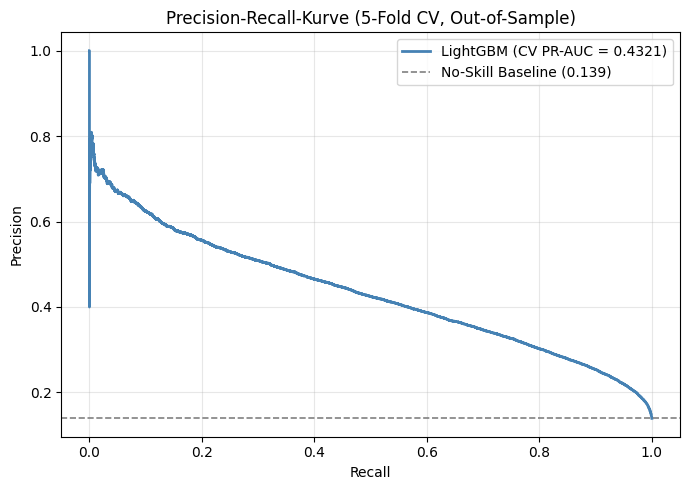

pr_curve.png gespeichert. CV PR-AUC (all folds combined) = 0.4321


In [13]:
# PR-Kurve aus CV-Predictions (Out-of-Sample)
# cross_val_predict gibt predict_proba-Outputs über alle Folds zurück
y_scores_cv = cross_val_predict(
    best_pipe, X_train_enriched, y_train,
    cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, y_scores_cv)
cv_prauc = average_precision_score(y_train, y_scores_cv)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, lw=2, color='steelblue',
        label=f'{best_model_name} (CV PR-AUC = {cv_prauc:.4f})')
ax.axhline(y=y_train.mean(), color='gray', linestyle='--', lw=1.2,
           label=f'No-Skill Baseline ({y_train.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall-Kurve (5-Fold CV, Out-of-Sample)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'pr_curve.png gespeichert. CV PR-AUC (all folds combined) = {cv_prauc:.4f}')

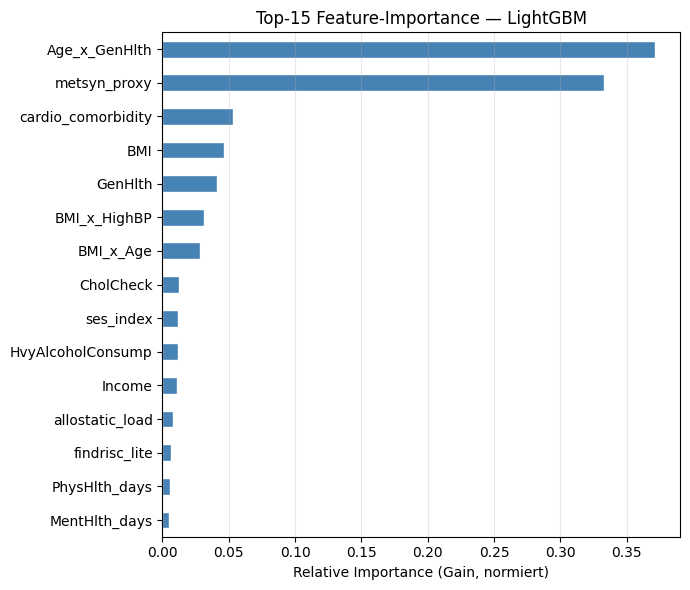

feature_importance.png gespeichert.

Top-15 Features (relative Importance, normiert):
Age_x_GenHlth         0.371643
metsyn_proxy          0.332607
cardio_comorbidity    0.053286
BMI                   0.046661
GenHlth               0.041371
BMI_x_HighBP          0.031077
BMI_x_Age             0.028172
CholCheck             0.012571
ses_index             0.011838
HvyAlcoholConsump     0.011608
Income                0.010660
allostatic_load       0.007940
findrisc_lite         0.006406
PhysHlth_days         0.005510
MentHlth_days         0.004600


In [14]:
# Feature-Importance (Top 15, normiert auf Summe 1)
def get_feature_importance(estimator, feature_names):
    """Extrahiert Importances — funktioniert mit Pipeline und bare Estimator."""
    from sklearn.pipeline import Pipeline
    model = estimator.steps[-1][1] if isinstance(estimator, Pipeline) else estimator
    if hasattr(model, 'feature_importances_'):
        return pd.Series(model.feature_importances_, index=feature_names)
    elif hasattr(model, 'coef_'):
        return pd.Series(np.abs(model.coef_[0]), index=feature_names)
    else:
        return None

feat_names = X_train_enriched.columns.tolist()
importance = get_feature_importance(best_pipe, feat_names)

if importance is not None:
    # Normieren auf Summe 1 (relative Wichtigkeit), damit Gain-Rohwerte
    # (z. B. LightGBM) nicht irreführend groß wirken
    importance = importance / importance.sum()
    top15 = importance.nlargest(15).sort_values()
    fig, ax = plt.subplots(figsize=(7, 6))
    top15.plot.barh(ax=ax, color='steelblue', edgecolor='white')
    ax.set_xlabel('Relative Importance (Gain, normiert)')
    ax.set_title(f'Top-15 Feature-Importance — {best_model_name}')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUTS_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('feature_importance.png gespeichert.')
    print(f'\nTop-15 Features (relative Importance, normiert):')
    print(top15.sort_values(ascending=False).to_string())
else:
    print(f'Feature-Importance für {best_model_name} nicht direkt verfügbar.')

**Interpretation:** Die PR-Kurve zeigt den Precision-Recall-Tradeoff über alle
CV-Folds. Die Fläche darunter (CV PR-AUC) ist eine Out-of-Sample-Schätzung der
Modellgüte — konservativer als die Trainings-PR-AUC, aber optimistischer als
die echte Test-PR-AUC (die noch eingefroren ist). Die Recall-Priorität folgt
der in NB01 (Cost Matrix) begründeten Entscheidung: im klinischen Screening-Kontext
sind falsch-negative Diagnosen teurer als falsch-positive.

Die Feature-Importance ist auf Summe 1 normiert (relative Wichtigkeit), damit
die rohen Gain-Werte von LightGBM (die im Absolutwert irreführend groß wirken
können) vergleichbar sind. Klinische Features wie `GenHlth`, `BMI` und `HighBP`
dominieren erwartungsgemäß — konsistent mit der Diabetes-Epidemiologie. Die
engineerten Interaktionsfeatures (`Age_x_GenHlth`, `BMI_x_Age`) tauchen ebenfalls
unter den Top-Features auf, was den Wert des Feature-Engineerings aus NB05 bestätigt.

## 10. Export — Übersicht

Alle Outputs werden nochmals gelistet, um die Vollständigkeit zu verifizieren.

In [15]:
expected_outputs = [
    MODELS_DIR  / 'best_model.pkl',
    OUTPUTS_DIR / 'cv_results_dummy.csv',
    OUTPUTS_DIR / 'cv_results_dedup.csv',
    OUTPUTS_DIR / 'cv_results_raw_vs_enriched.csv',
    OUTPUTS_DIR / 'cv_results_imbalance.csv',
    OUTPUTS_DIR / 'cv_results_models.csv',
    OUTPUTS_DIR / 'selected_features.json',
    OUTPUTS_DIR / 'pr_curve.png',
    OUTPUTS_DIR / 'feature_importance.png',
]

print('Export-Check:')
all_ok = True
for p in expected_outputs:
    exists = p.exists()
    status = '✓' if exists else '✗ FEHLT'
    print(f'  {status}  {p}')
    if not exists:
        all_ok = False

print(f'\nAlle Outputs vorhanden: {all_ok}')

Export-Check:
  ✓  ..\models\best_model.pkl
  ✓  ..\outputs\06_modeling\cv_results_dummy.csv
  ✓  ..\outputs\06_modeling\cv_results_dedup.csv
  ✓  ..\outputs\06_modeling\cv_results_raw_vs_enriched.csv
  ✓  ..\outputs\06_modeling\cv_results_imbalance.csv
  ✓  ..\outputs\06_modeling\cv_results_models.csv
  ✓  ..\outputs\06_modeling\selected_features.json
  ✓  ..\outputs\06_modeling\pr_curve.png
  ✓  ..\outputs\06_modeling\feature_importance.png

Alle Outputs vorhanden: True


## 11. Zusammenfassung

Tabellarische Befunde dieser Modellierungsphase. Alle methodischen Korrekturen
(RFECV-Pipeline-Fix, CholCheck-Ausschluss, normierte Feature-Importance) sind
in den Ergebnissen berücksichtigt.

In [16]:
# Dummy-Untergrenze
dummy_baseline = df_dummy['mean PR-AUC'].max()

# Duplikat-Effekt
if len(df_dedup_results) >= 2:
    prauc_mit_dups   = df_dedup_results.loc[df_dedup_results['Variante'] == 'Mit Duplikaten',   'mean PR-AUC'].values[0]
    prauc_ohne_dups  = df_dedup_results.loc[df_dedup_results['Variante'] == 'Ohne Duplikate',   'mean PR-AUC'].values[0]
    delta_dedup      = round(prauc_mit_dups - prauc_ohne_dups, 4)
    dedup_empfehlung = 'Ja' if (n_dups > 0 and abs(delta_dedup) > 0.002) else ('Nein' if n_dups == 0 else 'Grenzwertig')
else:
    delta_dedup = 0.0
    dedup_empfehlung = 'N/A'

# Feature-Engineering-Effekt
lr_raw  = df_fe.loc[(df_fe['Modell'] == 'LogReg') & (df_fe['Featureset'] == 'Raw 21'),      'mean PR-AUC'].values[0]
lr_enr  = df_fe.loc[(df_fe['Modell'] == 'LogReg') & (df_fe['Featureset'] == 'Enriched 32'), 'mean PR-AUC'].values[0]
xgb_raw = df_fe.loc[(df_fe['Modell'] == 'XGB')    & (df_fe['Featureset'] == 'Raw 21'),      'mean PR-AUC'].values[0]
xgb_enr = df_fe.loc[(df_fe['Modell'] == 'XGB')    & (df_fe['Featureset'] == 'Enriched 32'), 'mean PR-AUC'].values[0]

# Imbalance-Sieger
best_imb_row  = df_imb.loc[df_imb['mean PR-AUC'].idxmax()]

# Feature-Selektion Counts
n_enet  = len(selected_enet_list)
n_rfecv = len(selected_rfecv)
n_inter = len(intersection)

# Modellvergleich-Statistiken
n_models_total = len(df_compare)
n_models_ok    = len(df_compare[df_compare['mean PR-AUC'] != 'FEHLER'])
top3_str       = ' | '.join(top3)

summary_rows = [
    ('Dummy-Baseline PR-AUC (No-Skill)',        f'{dummy_baseline:.4f}',
     'Absolute Untergrenze; ≈ Klassen-Prävalenz'),
    ('Duplikate in X_train',                    f'{n_dups:,}',
     f'ΔPR-AUC = {delta_dedup:+.4f}; NB03-Korrektur empfohlen: {dedup_empfehlung}'),
    ('Feature-Engineering-Effekt (LogReg)',      f'{lr_enr - lr_raw:+.4f}',
     f'Raw {lr_raw:.4f} → Enriched {lr_enr:.4f}'),
    ('Feature-Engineering-Effekt (XGB)',         f'{xgb_enr - xgb_raw:+.4f}',
     f'Raw {xgb_raw:.4f} → Enriched {xgb_enr:.4f}'),
    ('Imbalance-Strategie-Sieger',               best_imb_row['Strategie'],
     f'PR-AUC = {best_imb_row["mean PR-AUC"]:.4f}'),
    ('RFECV-Implementierung',                    'Pipeline-Estimator (kein Leakage)',
     'Scaler wird pro RFECV-CV-Fold neu gefittet'),
    ('CholCheck-Ausschluss',                     'Explizit entfernt',
     'NB04: quasi-konstant (~96 % positiv), IV ≈ 0, kein Diskriminierungsbeitrag'),
    ('Feature-Selektion (Anzahl)',               f'EN={n_enet} | RFECV={n_rfecv} | Schnittmenge={n_inter}',
     'Von 32 Enriched-Features (CholCheck bereits ausgeschlossen)'),
    ('Modellvergleich Sektion 8',                f'{n_models_ok} / {n_models_total} Modelle erfolgreich',
     '6 Familien: Linear, Distanz, Einzelbaum, Bagging, Boosting, Neural Net'),
    ('Bestes Modell (Sektion 8)',                best_model_name,
     f'CV PR-AUC = {best_prauc:.4f} (ohne Hyperparameter-Tuning)'),
    ('Top-3 Familien für NB07',                  top3_str,
     'Diversitäts-Filter: max. 1 Boosting + beste andere Familien — für Stacking'),
    ('Feature-Importance',                       'Gain, normiert auf Summe 1',
     'Relative Wichtigkeit; rohe Gain-Werte wären irreführend groß'),
    ('Hyperparameter-Tuning',                    'Nicht durchgeführt',
     'Separates Notebook NB07'),
    ('Test-Evaluation',                          'Nicht durchgeführt',
     'X_test eingefroren; finale Eval in NB08'),
]

df_summary = pd.DataFrame(summary_rows, columns=['Aspekt', 'Wert', 'Anmerkung'])
print('\n=== Zusammenfassung NB06 Modeling ===')
for _, row in df_summary.iterrows():
    print(f'  {row["Aspekt"]:<42s} {str(row["Wert"]):>35s}   {row["Anmerkung"]}')

print(f'\nNächste Schritte:')
print('  - NB07: Hyperparameter-Tuning der Top-3 Kandidaten:')
print(f'          {top3}')
print('          LightGBM: num_leaves, min_child_samples, learning_rate,')
print('                    n_estimators, subsample, colsample_bytree')
print('          MLP:      hidden_layer_sizes, alpha, learning_rate_init')
print('          LogReg:   C, l1_ratio (ElasticNet)')
print('  - NB07/08: Stacking-Ensemble aus getunten Top-3 Base-Learnern')
print('             (Meta-Learner: LogReg) — Stacking erzeugt nur Mehrwert')
print('             mit getunten, gering korrelierten Bases')
print('  - NB08: Finale Evaluation, Threshold-Optimierung (Recall-Constraint NB01),')
print('          Kalibrierung (Brier-Score, Platt/Isotonic), Fairness-Analyse')


=== Zusammenfassung NB06 Modeling ===
  Dummy-Baseline PR-AUC (No-Skill)                                        0.1393   Absolute Untergrenze; ≈ Klassen-Prävalenz
  Duplikate in X_train                                                    18,580   ΔPR-AUC = -0.0022; NB03-Korrektur empfohlen: Ja
  Feature-Engineering-Effekt (LogReg)                                    +0.0169   Raw 0.4060 → Enriched 0.4229
  Feature-Engineering-Effekt (XGB)                                       -0.0023   Raw 0.4234 → Enriched 0.4211
  Imbalance-Strategie-Sieger                                    scale_pos_weight   PR-AUC = 0.4211
  RFECV-Implementierung                        Pipeline-Estimator (kein Leakage)   Scaler wird pro RFECV-CV-Fold neu gefittet
  CholCheck-Ausschluss                                         Explizit entfernt   NB04: quasi-konstant (~96 % positiv), IV ≈ 0, kein Diskriminierungsbeitrag
  Feature-Selektion (Anzahl)                  EN=28 | RFECV=19 | Schnittmenge=18   Von 32 Enriched